<a href="https://colab.research.google.com/github/Sg134-ch/Flyrank-ML-1/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
!git clone https://github.com/Sg134-ch/Flyrank-ML-1.git
%cd Flyrank-ML-1

import os
print(os.getcwd())
print(os.path.exists("data/raw/content_refresh_anonymized.csv"))

Cloning into 'Flyrank-ML-1'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 98 (delta 20), reused 79 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 1.84 MiB | 7.77 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/Flyrank-ML-1
/content/Flyrank-ML-1
True


In [3]:
import os
print(os.getcwd())

/content/Flyrank-ML-1


## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*


### Chosen Lane: Content Refresh Prioritization

I selected the **Content Refresh Prioritization** lane because organizations often manage thousands of webpages, making it impractical to manually review every page for declining performance. An intelligent ranking system can help SEO teams identify which pages should be reviewed first, allowing limited editorial resources to be focused where they are most valuable.

The anonymized starter dataset contains page-level SEO metrics, engagement signals, content characteristics, and historical performance labels, making it well suited for investigating whether observable signals can help prioritize content refresh decisions. Rather than replacing human judgment, the goal is to support decision-making by recommending pages that deserve manual review first.


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

### Research Question

**Can observable page-level SEO signals be used to identify webpages that should be prioritized for a content refresh review before significant performance decline occurs?**

### Decision

Which webpages should appear at the top of the content refresh queue?

### Unit of Analysis

Each observation represents one webpage.

### Model Output

A ranking score or probability indicating how likely a webpage is to require content refresh.

### Action

SEO specialists or content editors can:

- Update outdated information
- Improve keyword targeting
- Refresh metadata
- Expand content
- Improve internal linking

### Cost of Wrong Recommendations

**False Positive**
- Editorial time is wasted reviewing healthy pages.

**False Negative**
- Declining pages continue losing traffic and visibility.

### Why Machine Learning?

Rather than relying on a single heuristic, machine learning can combine multiple observable SEO signals such as impressions, CTR, page age, update history, and ranking position to estimate which pages are most likely to benefit from a content refresh. The objective is to support human decision-making by prioritizing review candidates rather than replacing editorial judgment.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [5]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset Overview")
print("-"*40)
print(f"Pages: {len(df):,}")
print(f"Columns: {df.shape[1]}")

# Create declining label if it doesn't already exist
if "is_declining_label" not in df.columns:
    df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

declining_rate = df["is_declining_label"].mean()
print(f"Declining rate: {declining_rate:.3f}")

corr = df["search_volume"].corr(df["impressions_90d"])
print(f"\nCorrelation (Search Volume vs Impressions): {corr:.3f}")

print("\nMedian Word Count by Trend")
print(df.groupby("trend_direction")["word_count"].median())

Dataset Overview
----------------------------------------
Pages: 30,000
Columns: 44
Declining rate: 0.542

Correlation (Search Volume vs Impressions): 0.001

Median Word Count by Trend
trend_direction
down      2909.0
flat      2698.5
new       2239.0
stable    2912.5
up        2847.5
Name: word_count, dtype: float64


## 3. Quick Look at the Data

The starter dataset contains **30,000 webpages** and **44 features**, providing a sufficiently large dataset for exploratory analysis and machine learning experiments.

Approximately **54.2% of the webpages are labelled as declining**, indicating that prioritizing content refresh is a meaningful prediction problem rather than an extremely rare event.

The correlation between **search volume** and **actual page impressions** is **0.001**, showing that keyword search volume alone is a poor predictor of page traffic.
The correlation between search volume and page impressions is only 0.001, indicating that keyword demand alone provides almost no information about how much traffic a page actually receives. This suggests that multiple features should be considered together when prioritizing content refresh.

Median word counts are very similar across performance groups (for example, **2909 words for declining pages** and **2847.5 words for growing pages**), suggesting that content length by itself is unlikely to explain search performance. This motivates using multiple observable features instead of relying on a single heuristic.

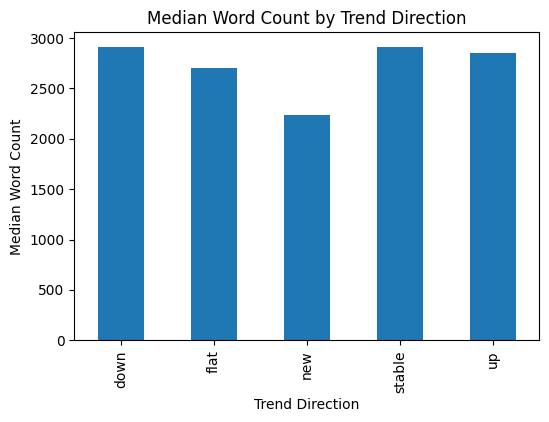

In [6]:
import matplotlib.pyplot as plt

median_wc = df.groupby("trend_direction")["word_count"].median()

plt.figure(figsize=(6,4))
median_wc.plot(kind="bar")
plt.title("Median Word Count by Trend Direction")
plt.ylabel("Median Word Count")
plt.xlabel("Trend Direction")
plt.show()

### Interpretation

The median word count is similar across most trend categories, particularly between growing and declining pages. This suggests that content length alone is unlikely to explain page performance and supports the need to consider multiple SEO signals when prioritizing content refresh.

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*



This project aims to identify **observed patterns** in the anonymized FlyRank dataset that may help prioritize webpages for content refresh. The machine learning model is intended to support decision-making by ranking pages that appear more likely to require review based on historical SEO signals.

The findings from this project should be interpreted as **observational** and **directional**, not causal. While the model may identify useful relationships between features such as impressions, CTR, content age, and page performance, it cannot determine why those relationships exist.

This work does **not** predict Google's search algorithm, prove that one SEO factor causes another, or guarantee future search performance. Instead, it provides a data-driven prioritization that can help SEO teams decide where to focus their manual review efforts.

## 5. Self-Check

- ✅ Every section is completed.
- ✅ The notebook runs from top to bottom.
- ✅ Real statistics are computed from the dataset.
- ✅ No private client information is included.
- ✅ Claims use careful language (observed, measured, directional, decision-support).
- ✅ Ready to commit under `work/notebooks/w01_research_question.ipynb`.